In [1]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns
import seaborn as seabornInstance 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.datasets import fetch_california_housing
%matplotlib inline

# Life Expectancy (WHO)

In [2]:
dataset = pd.read_csv('../datasets/Life Expectancy Data.csv')

In [3]:
dataset.shape

(2938, 22)

In [4]:
dataset.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [6]:
dataset = dataset.dropna()

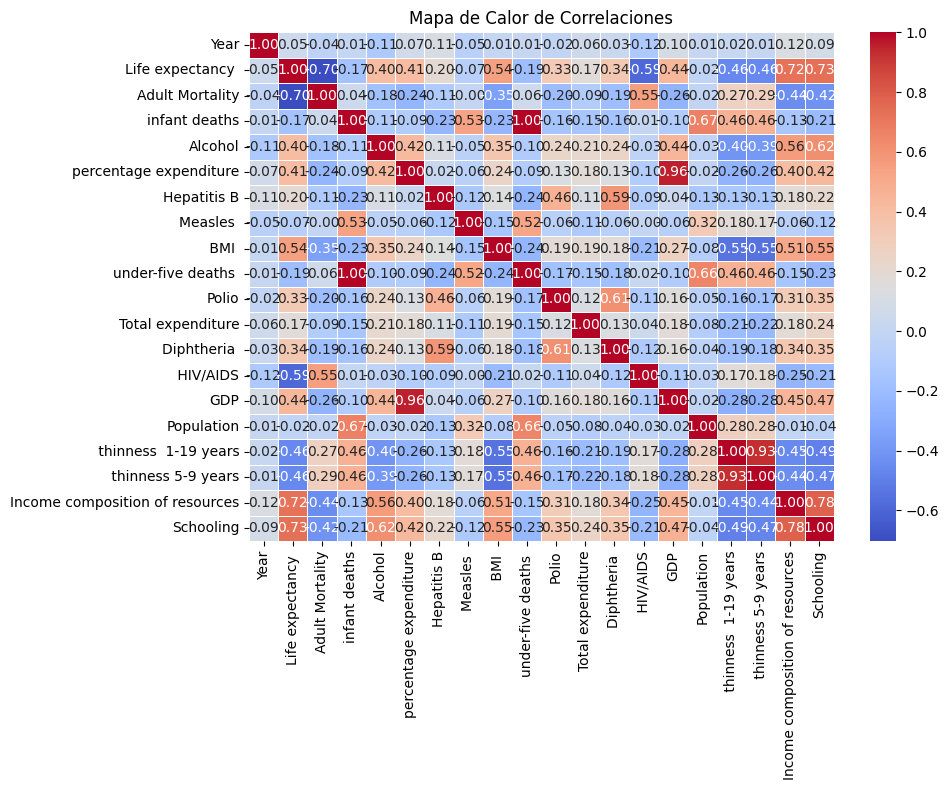

In [18]:
correlacion = dataset.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(correlacion, 
            annot=True,       
            cmap='coolwarm',  
            fmt=".2f",        
            linewidths=0.5)   

# 4. Ponemos título y mostramos
plt.title('Mapa de Calor de Correlaciones')
plt.tight_layout()
plt.show()

Escogemos Schooling y Life expectancy

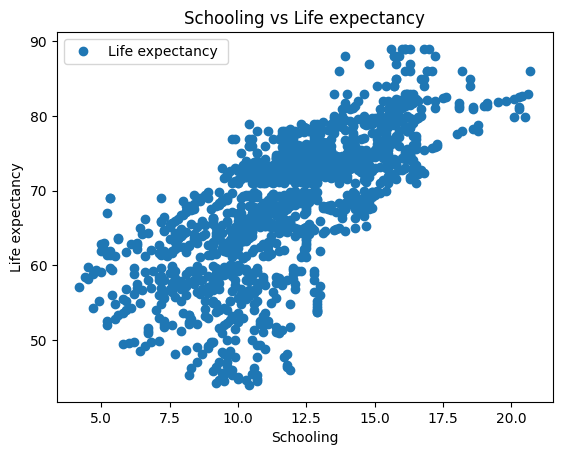

In [7]:
dataset.plot(x='Schooling', y='Life expectancy ', style='o')  
plt.title('Schooling vs Life expectancy')  
plt.xlabel('Schooling')  
plt.ylabel('Life expectancy')  
plt.show()

C:\Users\hugo_\AppData\Local\Temp\ipykernel_44108\600362105.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  seabornInstance.distplot(dataset['Life expectancy '], kde=True)


<Axes: xlabel='Life expectancy ', ylabel='Density'>

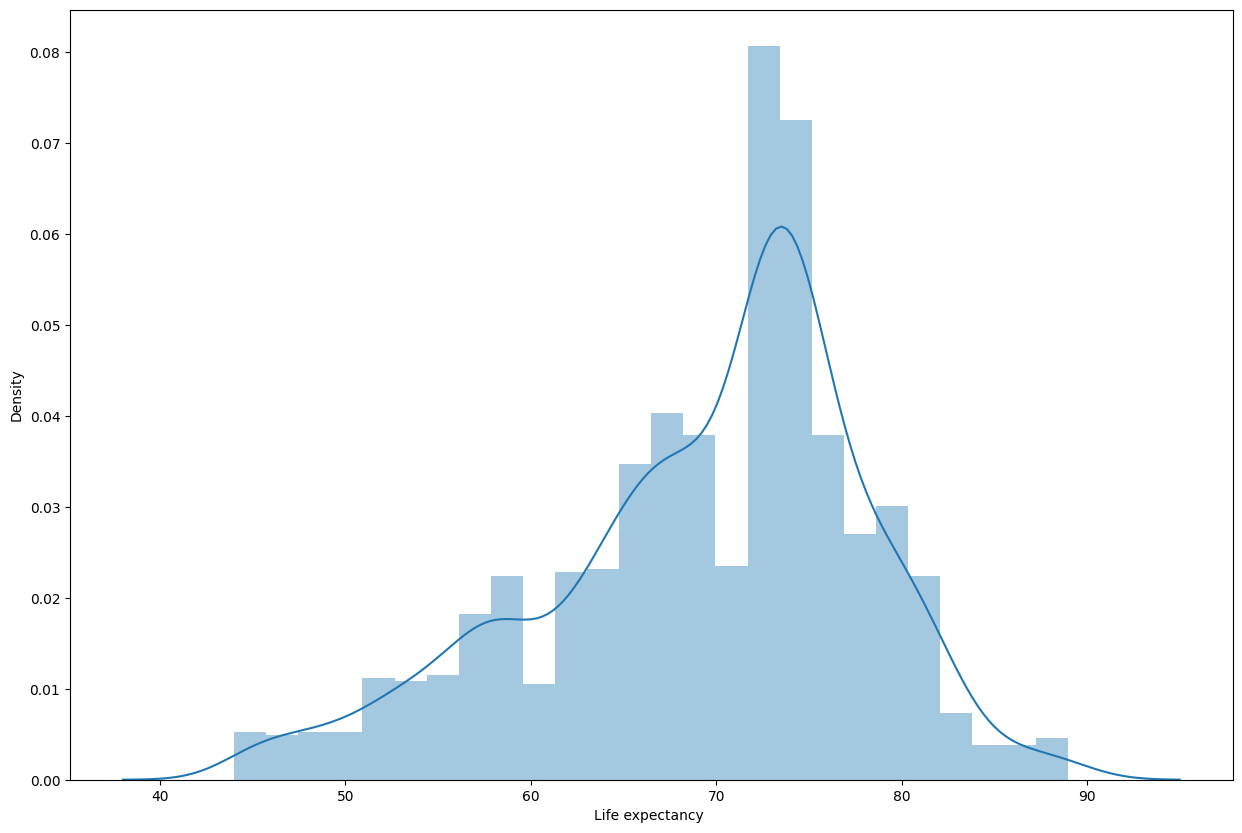

In [8]:
plt.figure(figsize=(15,10))
plt.tight_layout()
seabornInstance.distplot(dataset['Life expectancy '], kde=True)

In [9]:
X = dataset['Schooling'].values.reshape(-1,1)
y = dataset['Life expectancy '].values.reshape(-1,1)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [11]:
regressor = LinearRegression()  
regressor.fit(X_train, y_train) #training the algorithm

LinearRegression()

In [12]:
#To retrieve the intercept:
print(regressor.intercept_)

#For retrieving the slope:
print(regressor.coef_)

[41.70954528]
[[2.28398787]]


In [13]:
y_pred = regressor.predict(X_test)

In [14]:
df = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_pred.flatten()})
df

,Actual,Predicted
0,57.5,69.345798
1,81.7,78.481750
2,75.6,70.259394
3,56.6,64.092626
4,61.4,70.030995
...,...,...
325,72.7,71.172989
326,57.6,59.067853
327,75.4,76.197762
328,74.9,77.111357


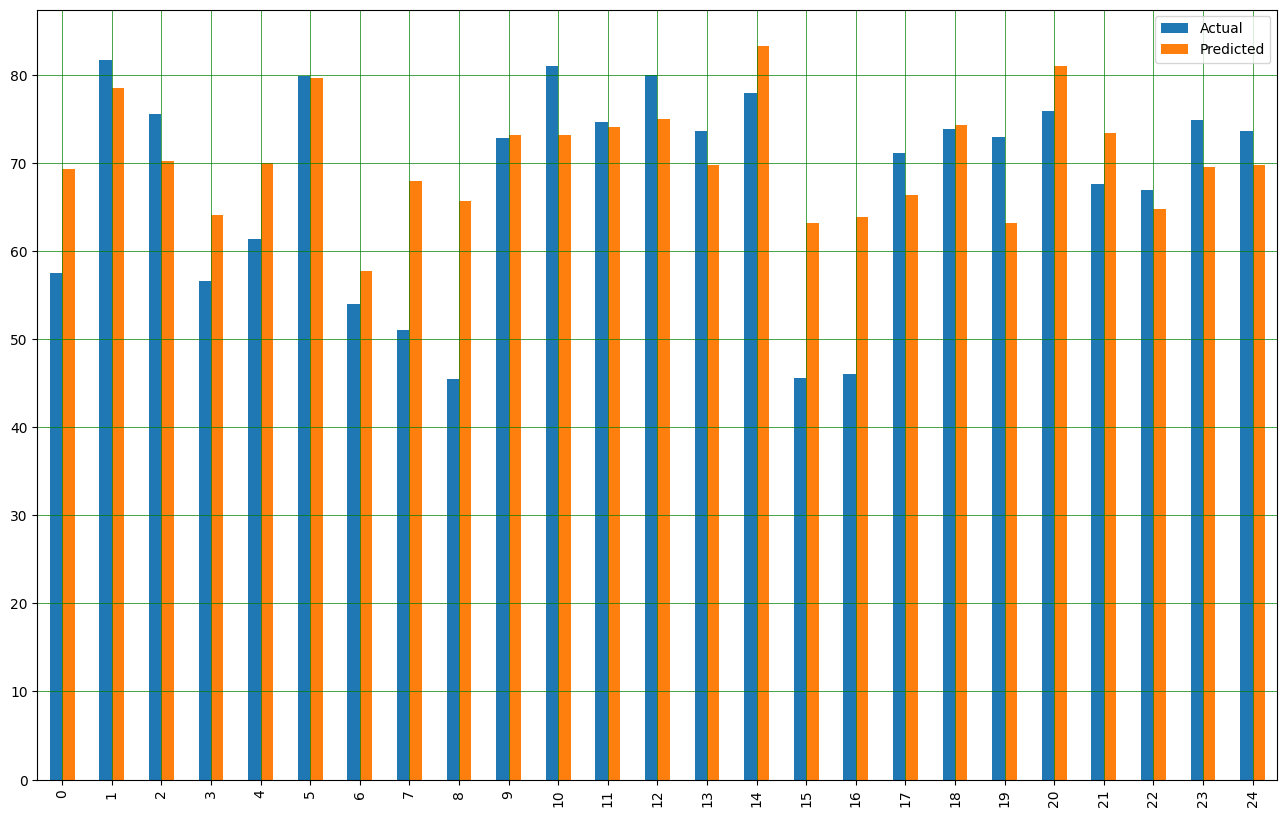

In [15]:
df1 = df.head(25)
df1.plot(kind='bar',figsize=(16,10))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

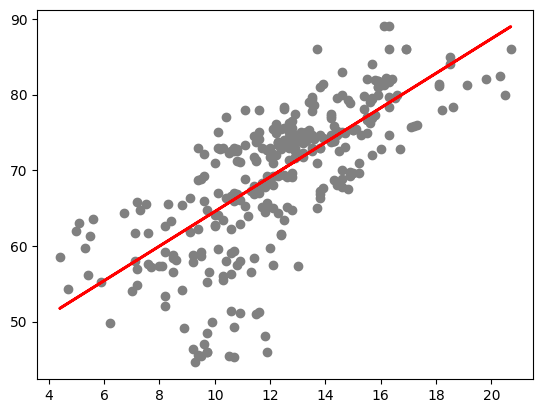

In [16]:
plt.scatter(X_test, y_test,  color='gray')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.show()

In [17]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 4.747935507961581
Mean Squared Error: 40.68712477840227
Root Mean Squared Error: 6.378645998830964


# Reflexión

Para el modelo de regresión lineal, elegí el conjunto de datos de Esperanza de Vida de la Organización Mundial de la Salud (OMS). Esta elección se basó en mi interés por analizar problemas complejos con un impacto real; el dataset cuenta con 22 variables que describen diversos factores demográficos, de salud y económicos de distintos países.

Mi primera gran tarea fue seleccionar el predictor adecuado para la variable de salida (esperanza de vida). Para fundamentar esta decisión, implementé un mapa de calor (heatmap) de correlación, lo cual me permitió identificar de manera visual y numérica qué variables tenían una relación lineal fuerte (como los años de escolaridad o el índice de composición de ingresos). La experiencia de adaptar el código del tutorial a mis necesidades fue fluida, pero tuve que realizar tareas de limpieza. Al ser un conjunto de datos del mundo real, contenía múltiples celdas vacías (NaN). Tuve que utilizar funciones como .dropna() para eliminar las filas nulas y garantizar una matriz limpia, evitando así que scikit-learn fallara al generar el modelo.

Los resultados obtenidos fueron bastante decentes, especialmente considerando que la esperanza de vida es un fenómeno multifactorial y aproximarlo mediante una regresión lineal simple es un reto estadístico complejo. Esta actividad me ayudó enormemente a aterrizar los conceptos teóricos de la clase. Pude comprender a fondo el workflow completo de una regresión lineal simple: desde la importancia de la exploración visual y limpieza estricta con pandas, hasta el entrenamiento y la interpretación de la línea de tendencia de nuestro modelo final.